# Weather-Only Flight Delay Classification

This notebook tests whether **weather data alone** can classify if a flight will be delayed.

Flight data is used only to:
1. create the target label, `Delayed`
2. get scheduled departure/arrival times
3. match each flight to origin and destination weather

The model features use only weather variables. It does **not** use airline, route, origin, destination, distance, scheduled elapsed time, departure hour, or arrival hour as predictors.

In [1]:
# Section 1 — Settings and imports

import gc
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")
pd.options.display.max_rows = 20
pd.options.display.max_columns = 50

FLIGHT_FILES = [
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2022.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2023.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2024.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2025.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2026.csv",
]

WEATHER_PATH = "/kaggle/input/datasets/sehamhakimothman/asos-weather-data-2019-2026/historical_weather_data_2019_2026.csv"

DELAY_THRESHOLD_MINUTES = 30
WEATHER_TOLERANCE = "3h"
PREDICTION_THRESHOLD = 0.50
TEST_SPLIT_DATE = "2025-01-01"
RANDOM_STATE = 42

FINAL_MODEL_FILE = "final_weather_only_delay_model.joblib"
FINAL_THRESHOLD_FILE = "final_weather_only_threshold.joblib"
FINAL_DATASET_FILE = "final_weather_only_modeling_dataset.parquet"

## Section 2 — Check input files

In [2]:
file_check = []
for file_path in FLIGHT_FILES:
    file_check.append({"file": Path(file_path).name, "exists": Path(file_path).exists(), "path": file_path})
file_check.append({"file": Path(WEATHER_PATH).name, "exists": Path(WEATHER_PATH).exists(), "path": WEATHER_PATH})

file_check_df = pd.DataFrame(file_check)
display(file_check_df)

if not file_check_df["exists"].all():
    raise FileNotFoundError("Some input files are missing. Check the paths above.")

,file,exists,path
0,bts_ontime_2022.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
1,bts_ontime_2023.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
2,bts_ontime_2024.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
3,bts_ontime_2025.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
4,bts_ontime_2026.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
5,historical_weather_data_2019_2026.csv,True,/kaggle/input/datasets/sehamhakimothman/asos-w...


## Section 3 — Load flight data for labels and weather matching

In [3]:
flight_cols = [
    "FlightDate", "Origin", "OriginState", "Dest", "DestState",
    "CRSDepTime", "CRSArrTime", "ArrDelayMinutes"
]

flight_parts = []
for file_path in FLIGHT_FILES:
    file_path = Path(file_path)
    header = pd.read_csv(file_path, nrows=0).columns.str.strip().tolist()
    usecols = [c for c in flight_cols if c in header]
    part = pd.read_csv(file_path, usecols=usecols, low_memory=False)
    part.columns = part.columns.str.strip()
    part["source_file"] = file_path.name
    flight_parts.append(part)

flights = pd.concat(flight_parts, ignore_index=True)
del flight_parts
gc.collect()

flights["FlightDate"] = pd.to_datetime(flights["FlightDate"], errors="coerce")
for col in ["Origin", "OriginState", "Dest", "DestState", "source_file"]:
    if col in flights.columns:
        flights[col] = flights[col].astype("string").str.strip().str.upper().astype("category")
for col in ["CRSDepTime", "CRSArrTime", "ArrDelayMinutes"]:
    if col in flights.columns:
        flights[col] = pd.to_numeric(flights[col], errors="coerce").astype("float32")

summary = pd.DataFrame({
    "item": ["Flight files loaded", "Flight rows", "First flight date", "Last flight date", "Memory usage MB"],
    "value": [len(FLIGHT_FILES), len(flights), flights["FlightDate"].min(), flights["FlightDate"].max(), round(flights.memory_usage(deep=True).sum()/1024**2, 2)]
})
display(summary)

,item,value
0,Flight files loaded,5
1,Flight rows,28201707
2,First flight date,2022-01-01 00:00:00
3,Last flight date,2026-01-31 00:00:00
4,Memory usage MB,726.23


## Section 4 — Create target and scheduled datetimes

,class,count,percentage
0,Not delayed,23835056,0.862421
1,Delayed,3802312,0.137579


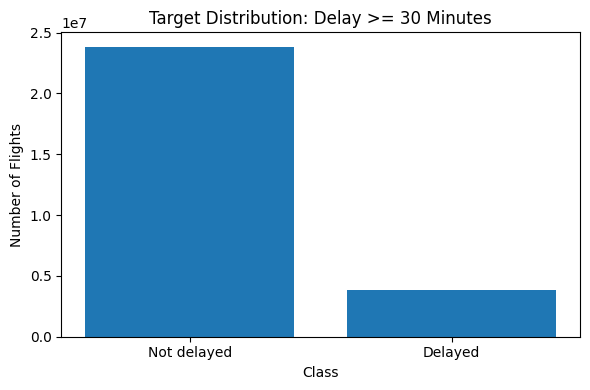

In [4]:
flights = flights.dropna(subset=["FlightDate", "Origin", "Dest", "CRSDepTime", "CRSArrTime", "ArrDelayMinutes"]).copy()
flights["Delayed"] = (flights["ArrDelayMinutes"] >= DELAY_THRESHOLD_MINUTES).astype("int8")

def make_local_datetime(date_series, time_series):
    time_num = pd.to_numeric(time_series, errors="coerce")
    hours = (time_num // 100).astype("float")
    minutes = (time_num % 100).astype("float")
    hours = hours.where(hours < 24, 0)
    return pd.to_datetime(date_series, errors="coerce") + pd.to_timedelta(hours, unit="h") + pd.to_timedelta(minutes, unit="m")

flights["sched_dep_local"] = make_local_datetime(flights["FlightDate"], flights["CRSDepTime"])
flights["sched_arr_local"] = make_local_datetime(flights["FlightDate"], flights["CRSArrTime"])

overnight = flights["sched_arr_local"] < flights["sched_dep_local"]
flights.loc[overnight, "sched_arr_local"] = flights.loc[overnight, "sched_arr_local"] + pd.Timedelta(days=1)

target_summary = flights["Delayed"].value_counts().rename(index={0:"Not delayed", 1:"Delayed"}).reset_index()
target_summary.columns = ["class", "count"]
target_summary["percentage"] = target_summary["count"] / target_summary["count"].sum()
display(target_summary)

plt.figure(figsize=(6,4))
plt.bar(target_summary["class"], target_summary["count"])
plt.title("Target Distribution: Delay >= 30 Minutes")
plt.xlabel("Class")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

## Section 5 — Convert scheduled departure and arrival to UTC

In [5]:
state_to_tz = {
    "AL":"America/Chicago", "AK":"America/Anchorage", "AZ":"America/Phoenix", "AR":"America/Chicago",
    "CA":"America/Los_Angeles", "CO":"America/Denver", "CT":"America/New_York", "DE":"America/New_York",
    "FL":"America/New_York", "GA":"America/New_York", "HI":"Pacific/Honolulu", "IA":"America/Chicago",
    "ID":"America/Denver", "IL":"America/Chicago", "IN":"America/Indiana/Indianapolis", "KS":"America/Chicago",
    "KY":"America/New_York", "LA":"America/Chicago", "MA":"America/New_York", "MD":"America/New_York",
    "ME":"America/New_York", "MI":"America/New_York", "MN":"America/Chicago", "MO":"America/Chicago",
    "MS":"America/Chicago", "MT":"America/Denver", "NC":"America/New_York", "ND":"America/Chicago",
    "NE":"America/Chicago", "NH":"America/New_York", "NJ":"America/New_York", "NM":"America/Denver",
    "NV":"America/Los_Angeles", "NY":"America/New_York", "OH":"America/New_York", "OK":"America/Chicago",
    "OR":"America/Los_Angeles", "PA":"America/New_York", "RI":"America/New_York", "SC":"America/New_York",
    "SD":"America/Chicago", "TN":"America/Chicago", "TX":"America/Chicago", "UT":"America/Denver",
    "VA":"America/New_York", "VT":"America/New_York", "WA":"America/Los_Angeles", "WI":"America/Chicago",
    "WV":"America/New_York", "WY":"America/Denver", "PR":"America/Puerto_Rico", "VI":"America/Puerto_Rico",
    "GU":"Pacific/Guam", "TT":"America/Puerto_Rico"
}

airport_tz_overrides = {
    "EVV":"America/Chicago", "SBN":"America/Indiana/Indianapolis", "CVG":"America/New_York", "OWB":"America/Chicago",
    "PAH":"America/Chicago", "BNA":"America/Chicago", "MEM":"America/Chicago", "TYS":"America/New_York",
    "TRI":"America/New_York", "CHA":"America/New_York", "ECP":"America/Chicago", "PNS":"America/Chicago",
    "VPS":"America/Chicago", "ELP":"America/Denver", "BOI":"America/Denver", "PIH":"America/Denver",
    "TWF":"America/Denver", "PHX":"America/Phoenix", "TUS":"America/Phoenix", "FLG":"America/Phoenix",
    "ANC":"America/Anchorage", "FAI":"America/Anchorage", "JNU":"America/Juneau", "KTN":"America/Sitka",
    "SIT":"America/Sitka", "OME":"America/Nome", "HNL":"Pacific/Honolulu", "OGG":"Pacific/Honolulu",
    "KOA":"Pacific/Honolulu", "LIH":"Pacific/Honolulu", "SJU":"America/Puerto_Rico", "STT":"America/Puerto_Rico",
    "STX":"America/Puerto_Rico", "GUM":"Pacific/Guam", "SPN":"Pacific/Saipan", "PPG":"Pacific/Pago_Pago"
}

flights["OriginTimezone"] = flights["OriginState"].astype("string").map(state_to_tz)
flights["OriginTimezone"] = flights["Origin"].astype("string").map(airport_tz_overrides).fillna(flights["OriginTimezone"])
flights["DestTimezone"] = flights["DestState"].astype("string").map(state_to_tz)
flights["DestTimezone"] = flights["Dest"].astype("string").map(airport_tz_overrides).fillna(flights["DestTimezone"])

def add_utc_time_by_timezone(df, local_col, tz_col, out_col):
    df[out_col] = pd.NaT
    for tz, idx in df.groupby(tz_col, dropna=True).groups.items():
        local_times = pd.to_datetime(df.loc[idx, local_col], errors="coerce")
        utc_times = local_times.dt.tz_localize(tz, ambiguous="NaT", nonexistent="shift_forward").dt.tz_convert("UTC").dt.tz_localize(None)
        df.loc[idx, out_col] = utc_times
    return df

flights = add_utc_time_by_timezone(flights, "sched_dep_local", "OriginTimezone", "sched_dep_utc")
flights = add_utc_time_by_timezone(flights, "sched_arr_local", "DestTimezone", "sched_arr_utc")

utc_summary = pd.DataFrame({
    "item": ["Flights before UTC filtering", "Flights with scheduled departure UTC", "Flights with scheduled arrival UTC"],
    "value": [len(flights), flights["sched_dep_utc"].notna().sum(), flights["sched_arr_utc"].notna().sum()]
})
display(utc_summary)

flights = flights[flights["sched_dep_utc"].notna() & flights["sched_arr_utc"].notna()].copy()
gc.collect()

,item,value
0,Flights before UTC filtering,27637368
1,Flights with scheduled departure UTC,27637341
2,Flights with scheduled arrival UTC,27637324


248

## Section 6 — Load weather data in chunks

In [6]:
station_special_map = {
    "PANC":"ANC", "PAFA":"FAI", "PAJN":"JNU", "PAKT":"KTN", "PASI":"SIT", "PAOM":"OME",
    "PABR":"BRW", "PABE":"BET", "PADQ":"ADQ", "PAHO":"HOM", "PAEN":"ENA", "PAVD":"VDZ",
    "PHNL":"HNL", "PHOG":"OGG", "PHKO":"KOA", "PHLI":"LIH", "PHTO":"ITO",
    "TJSJ":"SJU", "TJBQ":"BQN", "TJPS":"PSE", "TIST":"STT", "TISX":"STX",
    "PGUM":"GUM", "PGSN":"SPN", "NSTU":"PPG"
}

def station_to_iata(station_series):
    s = station_series.astype("string").str.strip().str.upper()
    mapped = s.map(station_special_map)
    k_rule = s.str.replace(r"^K(?=[A-Z]{3}$)", "", regex=True)
    return mapped.fillna(k_rule)

weather_cols = ["station", "valid", "tmpf", "dwpf", "relh", "drct", "sknt", "p01i", "alti", "mslp", "vsby", "gust", "skyc1", "skyc2", "wxcodes", "feel"]
weather_header = pd.read_csv(WEATHER_PATH, nrows=0).columns.str.strip().tolist()
weather_usecols = [c for c in weather_cols if c in weather_header]

needed_airports = set(pd.concat([flights["Origin"].astype("string"), flights["Dest"].astype("string")]).dropna().unique())
min_weather_time = min(flights["sched_dep_utc"].min(), flights["sched_arr_utc"].min()) - pd.Timedelta(WEATHER_TOLERANCE)
max_weather_time = max(flights["sched_dep_utc"].max(), flights["sched_arr_utc"].max()) + pd.Timedelta("1d")

weather_parts = []
chunk_size = 1_000_000

for chunk in pd.read_csv(WEATHER_PATH, usecols=weather_usecols, chunksize=chunk_size, low_memory=False, na_values=["M", ""]):
    chunk.columns = chunk.columns.str.strip()
    chunk["weather_iata"] = station_to_iata(chunk["station"])
    chunk = chunk[chunk["weather_iata"].isin(needed_airports)]
    if len(chunk) == 0:
        continue

    chunk["valid_utc"] = pd.to_datetime(chunk["valid"], errors="coerce", utc=True).dt.tz_localize(None)
    chunk = chunk[(chunk["valid_utc"] >= min_weather_time) & (chunk["valid_utc"] <= max_weather_time)]
    if len(chunk) == 0:
        continue

    for col in ["tmpf", "dwpf", "relh", "drct", "sknt", "p01i", "alti", "mslp", "vsby", "gust", "feel"]:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

    if "wxcodes" in chunk.columns:
        chunk["wxcodes"] = chunk["wxcodes"].fillna("NONE").astype("string")
    for col in ["skyc1", "skyc2"]:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna("NONE").astype("string")

    weather_parts.append(chunk)

if len(weather_parts) == 0:
    raise ValueError("No weather rows matched the needed airports and time range.")

weather = pd.concat(weather_parts, ignore_index=True)
del weather_parts
gc.collect()

weather_summary = pd.DataFrame({
    "item": ["Weather rows after filtering", "Weather columns", "Matched weather airports", "First weather time", "Last weather time", "Memory usage MB"],
    "value": [len(weather), weather.shape[1], weather["weather_iata"].nunique(), weather["valid_utc"].min(), weather["valid_utc"].max(), round(weather.memory_usage(deep=True).sum()/1024**2, 2)]
})
display(weather_summary)

,item,value
0,Weather rows after filtering,441399
1,Weather columns,18
2,Matched weather airports,10
3,First weather time,2021-12-31 16:31:00
4,Last weather time,2026-02-03 04:54:00
5,Memory usage MB,159.41


## Section 7 — Match flights with origin and destination weather

In [7]:
weather = weather.sort_values(["weather_iata", "valid_utc"]).reset_index(drop=True)

def merge_scheduled_weather(flights_df, weather_df, airport_col, time_col, prefix, tolerance=WEATHER_TOLERANCE):
    parts = []
    tolerance = pd.Timedelta(tolerance)
    weather_cols_to_prefix = [c for c in weather_df.columns if c not in ["station", "weather_iata", "valid", "valid_utc"]]
    flight_airports = set(flights_df[airport_col].astype("string").dropna().unique())
    weather_df = weather_df[weather_df["weather_iata"].isin(flight_airports)].copy()

    for airport, f_part in flights_df.groupby(airport_col, sort=False):
        w_part = weather_df[weather_df["weather_iata"] == str(airport)].copy()
        if len(w_part) == 0:
            continue
        merged = pd.merge_asof(
            f_part.sort_values(time_col),
            w_part.sort_values("valid_utc"),
            left_on=time_col,
            right_on="valid_utc",
            direction="backward",
            tolerance=tolerance
        )
        parts.append(merged)

    if len(parts) == 0:
        raise ValueError(f"No weather matches found for {prefix}.")

    out = pd.concat(parts, ignore_index=True)
    rename_map = {c: f"{prefix}_{c}" for c in weather_cols_to_prefix}
    rename_map.update({"valid_utc": f"{prefix}_valid_utc", "valid": f"{prefix}_valid", "station": f"{prefix}_station", "weather_iata": f"{prefix}_iata"})
    return out.rename(columns=rename_map)

model_data = merge_scheduled_weather(flights, weather, airport_col="Origin", time_col="sched_dep_utc", prefix="origin_wx")
model_data = model_data[model_data["origin_wx_valid_utc"].notna()].copy()

model_data = merge_scheduled_weather(model_data, weather, airport_col="Dest", time_col="sched_arr_utc", prefix="dest_wx")
model_data = model_data[model_data["dest_wx_valid_utc"].notna()].copy()

del weather, flights
gc.collect()

join_summary = pd.DataFrame({
    "item": ["Rows after origin + destination weather match", "Origin airports matched", "Destination airports matched", "Delayed rate", "Memory usage MB"],
    "value": [len(model_data), model_data["Origin"].nunique(), model_data["Dest"].nunique(), round(model_data["Delayed"].mean(), 4), round(model_data.memory_usage(deep=True).sum()/1024**2, 2)]
})
display(join_summary)

,item,value
0,Rows after origin + destination weather match,35709.0000
1,Origin airports matched,7.0000
2,Destination airports matched,7.0000
3,Delayed rate,0.1499
4,Memory usage MB,32.5200


## Section 8 — Create weather-only features

In [8]:
origin_codes = model_data["origin_wx_wxcodes"].fillna("NONE").astype("string")
dest_codes = model_data["dest_wx_wxcodes"].fillna("NONE").astype("string")

model_data["origin_wx_rain"] = origin_codes.str.contains("RA", regex=False).astype("int8")
model_data["origin_wx_snow"] = origin_codes.str.contains("SN", regex=False).astype("int8")
model_data["origin_wx_fog"] = origin_codes.str.contains("FG|BR", regex=True).astype("int8")
model_data["origin_wx_thunder"] = origin_codes.str.contains("TS", regex=False).astype("int8")

model_data["dest_wx_rain"] = dest_codes.str.contains("RA", regex=False).astype("int8")
model_data["dest_wx_snow"] = dest_codes.str.contains("SN", regex=False).astype("int8")
model_data["dest_wx_fog"] = dest_codes.str.contains("FG|BR", regex=True).astype("int8")
model_data["dest_wx_thunder"] = dest_codes.str.contains("TS", regex=False).astype("int8")

numeric_weather_features = [
    "origin_wx_tmpf", "origin_wx_dwpf", "origin_wx_relh", "origin_wx_drct", "origin_wx_sknt", "origin_wx_p01i", "origin_wx_alti", "origin_wx_mslp", "origin_wx_vsby", "origin_wx_gust", "origin_wx_feel",
    "origin_wx_rain", "origin_wx_snow", "origin_wx_fog", "origin_wx_thunder",
    "dest_wx_tmpf", "dest_wx_dwpf", "dest_wx_relh", "dest_wx_drct", "dest_wx_sknt", "dest_wx_p01i", "dest_wx_alti", "dest_wx_mslp", "dest_wx_vsby", "dest_wx_gust", "dest_wx_feel",
    "dest_wx_rain", "dest_wx_snow", "dest_wx_fog", "dest_wx_thunder"
]
numeric_weather_features = [c for c in numeric_weather_features if c in model_data.columns]

categorical_weather_features = ["origin_wx_skyc1", "origin_wx_skyc2", "dest_wx_skyc1", "dest_wx_skyc2"]
categorical_weather_features = [c for c in categorical_weather_features if c in model_data.columns]

all_weather_features = numeric_weather_features + categorical_weather_features

feature_summary = pd.DataFrame({
    "feature_type": ["numeric weather", "categorical weather", "total weather"],
    "count": [len(numeric_weather_features), len(categorical_weather_features), len(all_weather_features)]
})
display(feature_summary)
display(pd.DataFrame({"weather_features_used": all_weather_features}))

,feature_type,count
0,numeric weather,30
1,categorical weather,4
2,total weather,34


,weather_features_used
0,origin_wx_tmpf
1,origin_wx_dwpf
2,origin_wx_relh
3,origin_wx_drct
4,origin_wx_sknt
...,...
29,dest_wx_thunder
30,origin_wx_skyc1
31,origin_wx_skyc2
32,dest_wx_skyc1


## Section 9 — Train/test split

In [9]:
split_date = pd.Timestamp(TEST_SPLIT_DATE)
train_df = model_data[model_data["FlightDate"] < split_date].copy()
test_df = model_data[model_data["FlightDate"] >= split_date].copy()

if len(train_df) == 0 or len(test_df) == 0:
    train_df, test_df = train_test_split(model_data, test_size=0.2, random_state=RANDOM_STATE, stratify=model_data["Delayed"])

X_train = train_df[all_weather_features]
y_train = train_df["Delayed"].astype("int8")
X_test = test_df[all_weather_features]
y_test = test_df["Delayed"].astype("int8")

split_summary = pd.DataFrame({"dataset": ["train", "test"], "rows": [len(train_df), len(test_df)], "delayed_rate": [y_train.mean(), y_test.mean()]})
display(split_summary)

,dataset,rows,delayed_rate
0,train,21591,0.126117
1,test,14118,0.186287


## Section 10 — Train weather-only Random Forest

In [10]:
rf_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_weather_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", dtype=np.float32))]), categorical_weather_features),
    ],
    sparse_threshold=1.0
)

random_forest_model = Pipeline(steps=[
    ("preprocess", rf_preprocess),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
])

random_forest_model.fit(X_train, y_train)
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= PREDICTION_THRESHOLD).astype(int)

rf_metrics = pd.DataFrame([{
    "model": "Weather-only Random Forest", "delay_definition_minutes": DELAY_THRESHOLD_MINUTES, "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, rf_pred), "precision_delayed": precision_score(y_test, rf_pred, zero_division=0),
    "recall_delayed": recall_score(y_test, rf_pred, zero_division=0), "f1_delayed": f1_score(y_test, rf_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, rf_proba), "average_precision": average_precision_score(y_test, rf_proba)
}])
display(rf_metrics)

,model,delay_definition_minutes,prediction_threshold,accuracy,precision_delayed,recall_delayed,f1_delayed,roc_auc,average_precision
0,Weather-only Random Forest,30,0.5,0.800822,0.437328,0.241445,0.311122,0.665898,0.358474


## Section 11 — Train weather-only Neural Network

In [11]:
nn_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler(with_mean=False))]), numeric_weather_features),
        ("cat", Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", dtype=np.float32))]), categorical_weather_features),
    ],
    sparse_threshold=1.0
)

neural_network_model = Pipeline(steps=[
    ("preprocess", nn_preprocess),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=0.0005, batch_size=128, learning_rate_init=0.001, max_iter=80, early_stopping=True, validation_fraction=0.1, n_iter_no_change=8, random_state=RANDOM_STATE, verbose=False))
])

neural_network_model.fit(X_train, y_train)
nn_proba = neural_network_model.predict_proba(X_test)[:, 1]
nn_pred = (nn_proba >= PREDICTION_THRESHOLD).astype(int)

nn_metrics = pd.DataFrame([{
    "model": "Weather-only Neural Network", "delay_definition_minutes": DELAY_THRESHOLD_MINUTES, "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, nn_pred), "precision_delayed": precision_score(y_test, nn_pred, zero_division=0),
    "recall_delayed": recall_score(y_test, nn_pred, zero_division=0), "f1_delayed": f1_score(y_test, nn_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, nn_proba), "average_precision": average_precision_score(y_test, nn_proba)
}])
display(nn_metrics)

,model,delay_definition_minutes,prediction_threshold,accuracy,precision_delayed,recall_delayed,f1_delayed,roc_auc,average_precision
0,Weather-only Neural Network,30,0.5,0.815909,0.71831,0.019392,0.037764,0.627141,0.339316


## Section 12 — Compare models

,model,delay_definition_minutes,prediction_threshold,accuracy,precision_delayed,recall_delayed,f1_delayed,roc_auc,average_precision
0,Weather-only Random Forest,30,0.5,0.800822,0.437328,0.241445,0.311122,0.665898,0.358474
1,Weather-only Neural Network,30,0.5,0.815909,0.718310,0.019392,0.037764,0.627141,0.339316


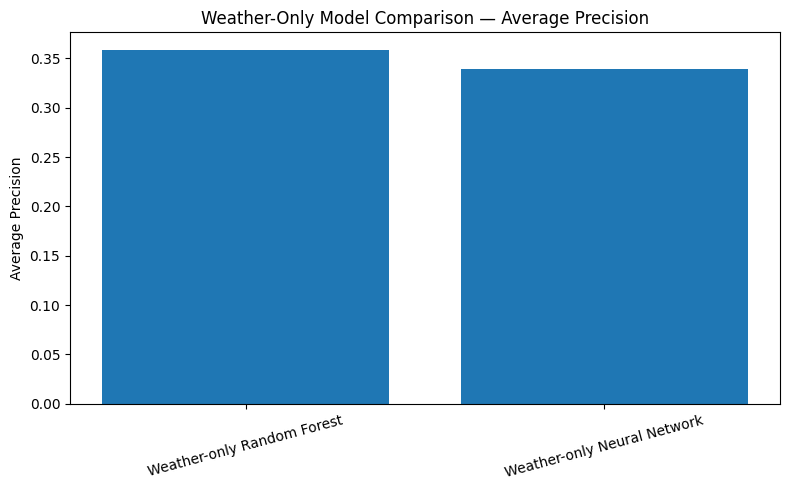

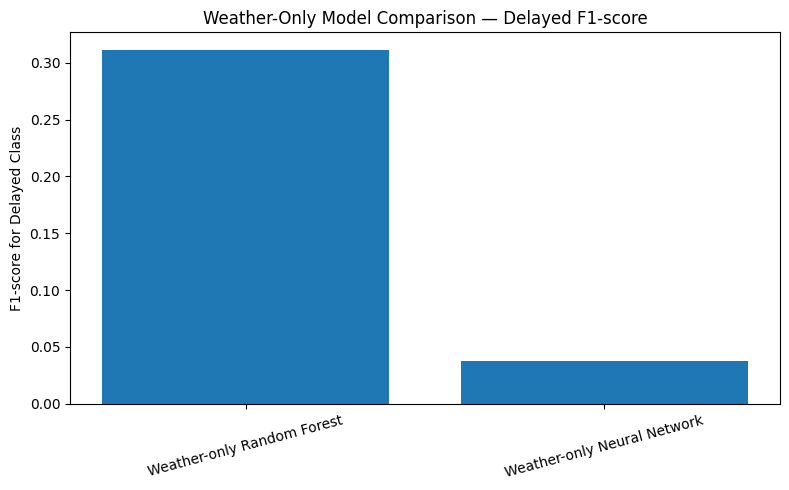

In [12]:
model_comparison = pd.concat([rf_metrics, nn_metrics], ignore_index=True)
display(model_comparison.sort_values(["average_precision", "roc_auc"], ascending=False).reset_index(drop=True))

plt.figure(figsize=(8,5))
plt.bar(model_comparison["model"], model_comparison["average_precision"])
plt.title("Weather-Only Model Comparison — Average Precision")
plt.ylabel("Average Precision")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(model_comparison["model"], model_comparison["f1_delayed"])
plt.title("Weather-Only Model Comparison — Delayed F1-score")
plt.ylabel("F1-score for Delayed Class")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Section 13 — Confusion matrices

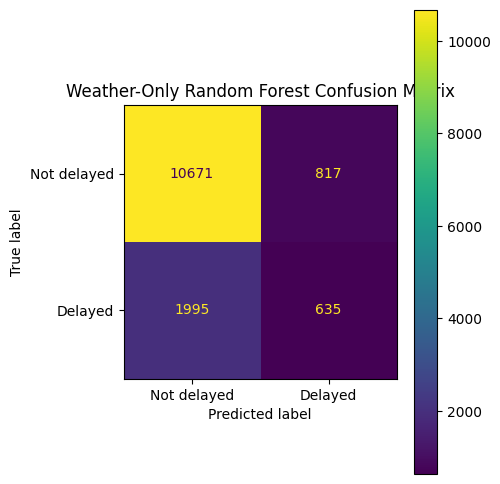

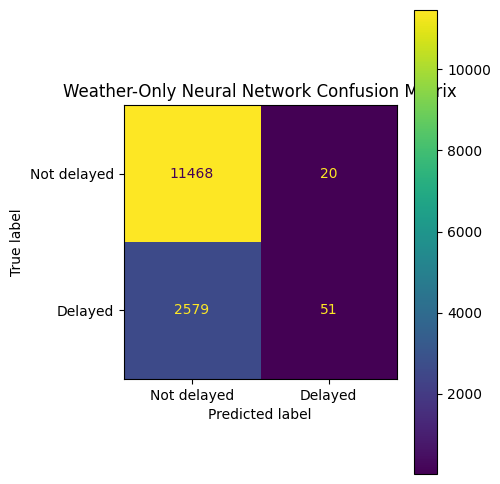

In [13]:
fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["Not delayed", "Delayed"], ax=ax, values_format="d")
ax.set_title("Weather-Only Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_test, nn_pred, display_labels=["Not delayed", "Delayed"], ax=ax, values_format="d")
ax.set_title("Weather-Only Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

## Section 14 — ROC and precision-recall curves

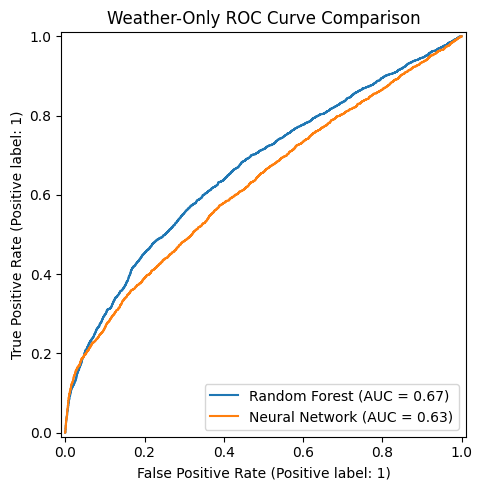

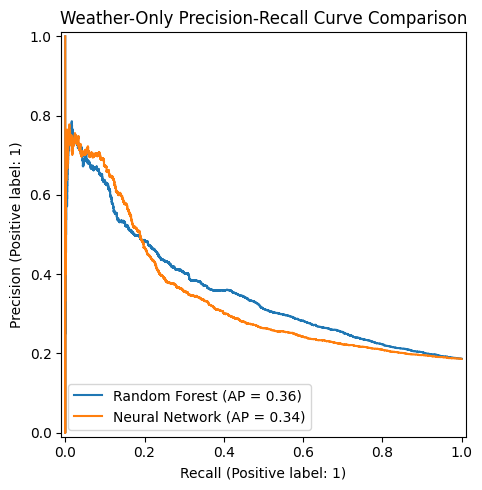

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, nn_proba, name="Neural Network", ax=ax)
ax.set_title("Weather-Only ROC Curve Comparison")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, nn_proba, name="Neural Network", ax=ax)
ax.set_title("Weather-Only Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

## Section 15 — Threshold comparison

,model,threshold,accuracy,precision_delayed,recall_delayed,f1_delayed
0,Weather-only Random Forest,0.20,0.270081,0.195847,0.939544,0.324129
1,Weather-only Random Forest,0.25,0.400907,0.214594,0.833080,0.341277
2,Weather-only Random Forest,0.30,0.542924,0.247657,0.713308,0.367663
3,Weather-only Random Forest,0.35,0.657600,0.289775,0.577567,0.385925
4,Weather-only Random Forest,0.40,0.735019,0.341059,0.453232,0.389224
...,...,...,...,...,...,...
21,Weather-only Neural Network,0.60,0.814775,0.741935,0.008745,0.017287
22,Weather-only Neural Network,0.65,0.814280,0.681818,0.005703,0.011312
23,Weather-only Neural Network,0.70,0.814350,0.764706,0.004943,0.009822
24,Weather-only Neural Network,0.75,0.813925,0.666667,0.002281,0.004547


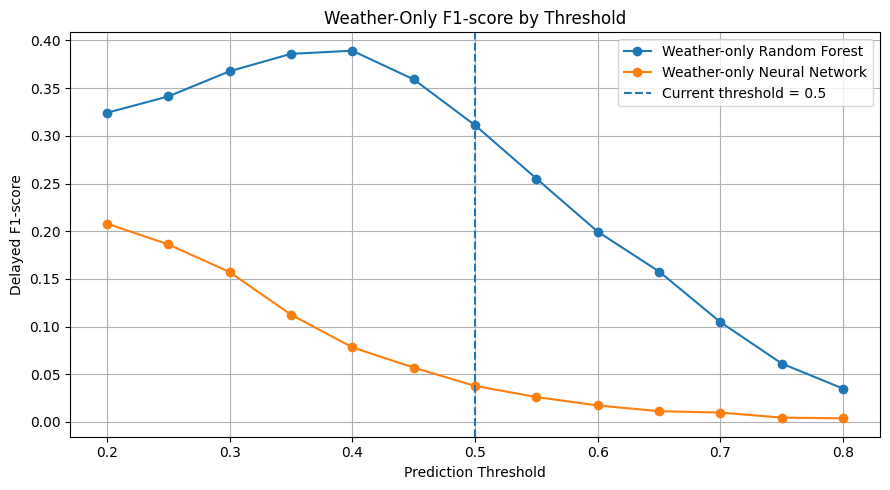

In [15]:
threshold_values = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for model_name, proba in [("Weather-only Random Forest", rf_proba), ("Weather-only Neural Network", nn_proba)]:
    for threshold in threshold_values:
        pred_t = (proba >= threshold).astype(int)
        threshold_rows.append({
            "model": model_name, "threshold": round(float(threshold), 2),
            "accuracy": accuracy_score(y_test, pred_t),
            "precision_delayed": precision_score(y_test, pred_t, zero_division=0),
            "recall_delayed": recall_score(y_test, pred_t, zero_division=0),
            "f1_delayed": f1_score(y_test, pred_t, zero_division=0)
        })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure(figsize=(9,5))
for model_name in threshold_df["model"].unique():
    part = threshold_df[threshold_df["model"] == model_name]
    plt.plot(part["threshold"], part["f1_delayed"], marker="o", label=model_name)
plt.axvline(PREDICTION_THRESHOLD, linestyle="--", label=f"Current threshold = {PREDICTION_THRESHOLD}")
plt.xlabel("Prediction Threshold")
plt.ylabel("Delayed F1-score")
plt.title("Weather-Only F1-score by Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 16 — Select final weather-only model

In [16]:
best_model_name = model_comparison.sort_values(["average_precision", "roc_auc"], ascending=False).iloc[0]["model"]

if best_model_name == "Weather-only Random Forest":
    final_model_template = "Random Forest"
else:
    final_model_template = "Neural Network"

selected_summary = pd.DataFrame({
    "item": ["Selected weather-only model", "Selection rule", "Prediction threshold", "Features allowed"],
    "value": [best_model_name, "Highest average precision, then ROC AUC", PREDICTION_THRESHOLD, "Weather features only"]
})
display(selected_summary)

,item,value
0,Selected weather-only model,Weather-only Random Forest
1,Selection rule,"Highest average precision, then ROC AUC"
2,Prediction threshold,0.5
3,Features allowed,Weather features only


## Section 17 — Train final selected weather-only model on all prepared rows

In [17]:
final_X = model_data[all_weather_features]
final_y = model_data["Delayed"].astype("int8")

if final_model_template == "Random Forest":
    final_model = Pipeline(steps=[
        ("preprocess", rf_preprocess),
        ("model", RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))
    ])
else:
    final_model = Pipeline(steps=[
        ("preprocess", nn_preprocess),
        ("model", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=0.0005, batch_size=512, learning_rate_init=0.001, max_iter=80, early_stopping=True, validation_fraction=0.1, n_iter_no_change=8, random_state=RANDOM_STATE, verbose=False))
    ])

final_model.fit(final_X, final_y)

final_training_summary = pd.DataFrame({
    "item": ["Final weather-only model", "Rows used for final training", "Delay definition", "Weather features used", "Prediction threshold"],
    "value": [final_model_template, len(final_X), f"ArrDelayMinutes >= {DELAY_THRESHOLD_MINUTES}", len(all_weather_features), PREDICTION_THRESHOLD]
})
display(final_training_summary)

,item,value
0,Final weather-only model,Random Forest
1,Rows used for final training,35709
2,Delay definition,ArrDelayMinutes >= 30
3,Weather features used,34
4,Prediction threshold,0.5


## Section 18 — Final model sanity check

,sample_rows,accuracy,precision_delayed,recall_delayed,f1_delayed
0,35709,0.900613,0.647966,0.737904,0.690017


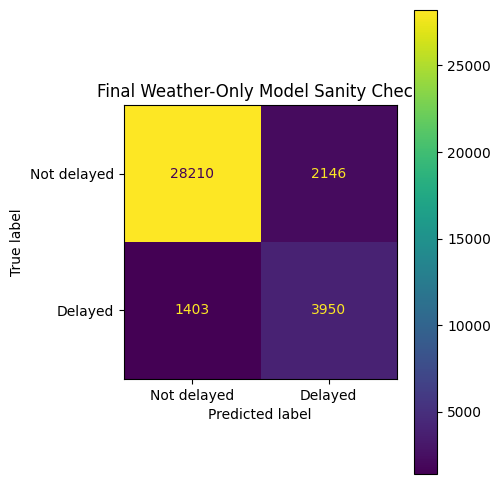

13744

In [18]:
if len(final_X) > 200_000:
    sanity_sample, _ = train_test_split(model_data, train_size=200_000, random_state=RANDOM_STATE, stratify=model_data["Delayed"])
else:
    sanity_sample = model_data.copy()

X_sanity = sanity_sample[all_weather_features]
y_sanity = sanity_sample["Delayed"].astype("int8")

sanity_proba = final_model.predict_proba(X_sanity)[:, 1]
sanity_pred = (sanity_proba >= PREDICTION_THRESHOLD).astype(int)

sanity_metrics = pd.DataFrame([{
    "sample_rows": len(sanity_sample),
    "accuracy": accuracy_score(y_sanity, sanity_pred),
    "precision_delayed": precision_score(y_sanity, sanity_pred, zero_division=0),
    "recall_delayed": recall_score(y_sanity, sanity_pred, zero_division=0),
    "f1_delayed": f1_score(y_sanity, sanity_pred, zero_division=0)
}])
display(sanity_metrics)

fig, ax = plt.subplots(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(y_sanity, sanity_pred, display_labels=["Not delayed", "Delayed"], ax=ax, values_format="d")
ax.set_title("Final Weather-Only Model Sanity Check")
plt.tight_layout()
plt.show()

del sanity_sample, X_sanity, y_sanity, sanity_proba, sanity_pred
gc.collect()

## Section 19 — Save final weather-only model, threshold, and dataset

In [19]:
joblib.dump(final_model, FINAL_MODEL_FILE)
joblib.dump(PREDICTION_THRESHOLD, FINAL_THRESHOLD_FILE)

save_cols = all_weather_features + ["Delayed", "FlightDate", "sched_dep_utc", "sched_arr_utc", "Origin", "Dest"]
save_cols = list(dict.fromkeys([c for c in save_cols if c in model_data.columns]))
model_data[save_cols].to_parquet(FINAL_DATASET_FILE, index=False)

saved_files = pd.DataFrame({
    "file": [FINAL_MODEL_FILE, FINAL_THRESHOLD_FILE, FINAL_DATASET_FILE],
    "exists": [Path(FINAL_MODEL_FILE).exists(), Path(FINAL_THRESHOLD_FILE).exists(), Path(FINAL_DATASET_FILE).exists()],
    "size_MB": [
        round(Path(FINAL_MODEL_FILE).stat().st_size/1024**2, 2) if Path(FINAL_MODEL_FILE).exists() else None,
        round(Path(FINAL_THRESHOLD_FILE).stat().st_size/1024**2, 2) if Path(FINAL_THRESHOLD_FILE).exists() else None,
        round(Path(FINAL_DATASET_FILE).stat().st_size/1024**2, 2) if Path(FINAL_DATASET_FILE).exists() else None,
    ]
})
display(saved_files)

,file,exists,size_MB
0,final_weather_only_delay_model.joblib,True,35.08
1,final_weather_only_threshold.joblib,True,0.00
2,final_weather_only_modeling_dataset.parquet,True,1.46


## Section 20 — Test loading the saved model

In [20]:
loaded_model = joblib.load(FINAL_MODEL_FILE)
loaded_threshold = joblib.load(FINAL_THRESHOLD_FILE)

sample_rows = final_X.head(10).copy()
sample_proba = loaded_model.predict_proba(sample_rows)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)

sample_output = sample_rows.copy()
sample_output["delay_probability"] = sample_proba
sample_output["predicted_delayed"] = sample_pred

display(sample_output)

,origin_wx_tmpf,origin_wx_dwpf,origin_wx_relh,origin_wx_drct,origin_wx_sknt,origin_wx_p01i,origin_wx_alti,origin_wx_mslp,origin_wx_vsby,origin_wx_gust,origin_wx_feel,origin_wx_rain,origin_wx_snow,origin_wx_fog,origin_wx_thunder,dest_wx_tmpf,dest_wx_dwpf,dest_wx_relh,dest_wx_drct,dest_wx_sknt,dest_wx_p01i,dest_wx_alti,dest_wx_mslp,dest_wx_vsby,dest_wx_gust,dest_wx_feel,dest_wx_rain,dest_wx_snow,dest_wx_fog,dest_wx_thunder,origin_wx_skyc1,origin_wx_skyc2,dest_wx_skyc1,dest_wx_skyc2,delay_probability,predicted_delayed
0,33.0,28.0,81.300003,40.0,15.0,NaN,29.799999,NaN,2.0,27.0,22.209999,0,1,0,0,30.9,28.0,88.839996,40.0,11.0,0.05,29.709999,1006.599976,0.5,25.0,21.080000,0,1,1,0,OVC,NONE,OVC,NONE,0.862798,1
1,23.0,14.0,67.959999,330.0,4.0,0.0,30.219999,1024.599976,10.0,NaN,16.910000,0,0,0,0,10.9,1.9,66.410004,310.0,8.0,0.00,30.320000,1028.199951,10.0,NaN,-1.880000,0,0,0,0,FEW,FEW,OVC,NONE,0.444383,0
2,14.0,3.0,60.939999,240.0,7.0,0.0,30.360001,1029.300049,10.0,NaN,2.840000,0,0,0,0,12.9,1.0,58.290001,190.0,7.0,0.00,30.410000,1031.400024,10.0,NaN,1.500000,0,0,0,0,CLR,NONE,CLR,NONE,0.227291,0
3,21.0,0.0,39.189999,210.0,8.0,0.0,30.290001,1027.000000,10.0,NaN,10.560000,0,0,0,0,21.9,10.0,59.630001,190.0,12.0,0.00,30.340000,1028.699951,10.0,NaN,9.150000,0,0,0,0,FEW,NONE,CLR,NONE,0.221482,0
4,19.9,3.0,47.220001,220.0,9.0,0.0,30.290001,1027.000000,10.0,NaN,8.470000,0,0,0,0,21.0,12.0,67.709999,190.0,9.0,0.00,30.320000,1028.000000,10.0,NaN,9.840000,0,0,0,0,FEW,NONE,CLR,NONE,0.202881,0
5,32.0,21.0,63.450001,190.0,10.0,0.0,29.940001,1014.599976,10.0,17.0,22.969999,0,0,0,0,33.0,25.0,71.820000,170.0,18.0,0.00,29.840000,1011.200012,10.0,26.0,21.200001,0,0,0,0,OVC,NONE,CLR,NONE,0.214708,0
6,32.0,21.9,65.919998,170.0,12.0,0.0,29.700001,1006.599976,10.0,20.0,22.000000,0,0,0,0,33.0,24.1,69.169998,180.0,18.0,0.00,29.639999,1004.500000,10.0,27.0,21.200001,0,0,0,0,SCT,OVC,CLR,NONE,0.281301,0
7,12.9,4.0,66.669998,250.0,22.0,NaN,29.709999,NaN,3.0,33.0,-7.000000,0,1,0,0,12.9,3.0,63.959999,270.0,18.0,NaN,29.920000,1013.900024,6.0,28.0,-5.390000,0,0,0,0,BKN,OVC,BKN,OVC,0.850811,1
8,12.0,4.0,69.379997,250.0,18.0,NaN,29.830000,NaN,5.0,35.0,-6.580000,0,1,0,0,10.9,-0.9,58.259998,280.0,7.0,0.00,30.000000,1017.099976,10.0,NaN,-0.940000,0,0,0,0,BKN,NONE,CLR,NONE,0.719537,1
9,12.9,4.0,66.669998,280.0,11.0,NaN,30.059999,NaN,10.0,NaN,-1.670000,0,1,0,0,1.9,-7.0,65.199997,300.0,12.0,0.00,30.219999,1025.099976,10.0,18.0,-16.309999,0,0,0,0,FEW,BKN,CLR,NONE,0.531308,1


## Section 21 — Final project conclusion

In [21]:
final_conclusion = (
    "This notebook tests whether weather data alone can classify if a flight will be delayed. "
    "Flight data is used only to define the target label and to match flights with the correct origin and destination weather observations. "
    "The model features include only weather variables such as temperature, humidity, wind speed, precipitation, pressure, visibility, cloud coverage, and weather event flags. "
    "No airline, airport, route, distance, scheduled elapsed time, departure hour, or arrival hour features are used as predictors. "
    "Random Forest and Neural Network models are trained and compared using classification metrics and graphs."
)
print(final_conclusion)

This notebook tests whether weather data alone can classify if a flight will be delayed. Flight data is used only to define the target label and to match flights with the correct origin and destination weather observations. The model features include only weather variables such as temperature, humidity, wind speed, precipitation, pressure, visibility, cloud coverage, and weather event flags. No airline, airport, route, distance, scheduled elapsed time, departure hour, or arrival hour features are used as predictors. Random Forest and Neural Network models are trained and compared using classification metrics and graphs.
